To ensure I am ready in the next session, here is the summary of our current state:Dataset: 2,199 molecules with PolyBERT fingerprints (600-D) + 1-D Time feature.Current Best DNN: $R^2 \approx 0.40$ (Ensemble) on the full test set; $R^2 \approx 0.73$ on the 85% "core" data.Goal: Compare DNN performance against AutoGluon Tabular to decide if we should shrink the training set (remove outliers permanently) before fine-tuning on polymers.Next Architecture: Few-shot frozen layer transfer learning for polymer biodegradation.Educating on the 60-20-20 Split & StratificationYou asked if a 60-20-20 split with Stratified Cross-Validation is possible in AutoGluon.

Yes, it is possible, but with a technical nuance: In Regression, we don't do "Stratified" splitting in the same way as Classification (where you balance classes). Instead, we do Quantile Stratification, ensuring the distribution of the biodegradation percentages (0 to 1) is identical in the Train, Val, and Test sets.AutoGluon handles this beautifully. It will train on the 60%, use the 20% validation to "stop" the training of individual models (like XGBoost, CatBoost, or Weighted Ensembles), and we will hold out the final 20% for the Parity Plot and Kinetic Curves.

## 1. Cell 2: GPU Availability Check
Run this cell to ensure your A100 is visible and we select the one with the most free memory.

In [1]:
import torch
import os

def select_gpu():
    if torch.cuda.is_available():
        gpu_count = torch.cuda.device_count()
        print(f"✅ Found {gpu_count} GPUs.")
        
        # Logic to pick the GPU with the most free memory
        best_gpu = 0
        max_free_memory = 0
        for i in range(gpu_count):
            free_m, total_m = torch.cuda.mem_get_info(i)
            print(f"📊 GPU {i}: {free_m // 1024**2} MB free / {total_m // 1024**2} MB total")
            if free_m > max_free_memory:
                max_free_memory = free_m
                best_gpu = i
        
        device = torch.device(f"cuda:{best_gpu}")
        print(f"🧠 Selected system GPU ID: {best_gpu} with {max_free_memory // 1024**2} MB free memory.")
    else:
        device = torch.device("cpu")
        print("⚠️ GPU not available, using CPU.")
    return device

device = select_gpu()

✅ Found 4 GPUs.
📊 GPU 0: 37457 MB free / 40326 MB total
📊 GPU 1: 7670 MB free / 40326 MB total
📊 GPU 2: 8246 MB free / 40326 MB total
📊 GPU 3: 7618 MB free / 40326 MB total
🧠 Selected system GPU ID: 0 with 37457 MB free memory.


## Cell 1: Importing Libraries
We start by importing AutoGluon and the standard tools for chemistry data.

In [2]:
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from autogluon.tabular import TabularPredictor, TabularDataset

# Set random seed for reproducibility
RANDOM_SEED = 42
print("Libraries imported successfully.")

Libraries imported successfully.


/home/sunil/.cache/pypoetry/virtualenvs/poetry-demo-9b10jFFD-py3.10/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Cell 2: Data Loading and 600-D Fingerprint Expansion
Since your fingerprints are currently stored as strings in one column, we must "expand" them into 600 individual columns so the model can see every dimension of the molecule.

In [5]:
# Path to your file
file_path = '/home/sunil/am2/poetry-demo/AM2_Poly_biodegradebilty/Autogluon_Cleaned_Mol_Model/Tox_Cleaned_SMILE_FP.csv'

# Load the data
df = pd.read_csv(file_path)

# 1. Convert string lists back into actual Python lists
df['fingerprints'] = df['fingerprints'].apply(ast.literal_eval)

# 2. Expand fingerprints into 600 separate columns (fp_0 to fp_599)
fp_df = pd.DataFrame(df['fingerprints'].tolist(), index=df.index).add_prefix('fp_')

# 3. Combine with 'time_day' and target 'biodegradation'
full_df = pd.concat([fp_df, df[['time_day', 'biodegradation']]], axis=1)

print(f"Data Expanded. Total shape: {full_df.shape}")
full_df

Data Expanded. Total shape: (1712, 602)


,fp_0,fp_1,fp_2,fp_3,fp_4,fp_5,fp_6,fp_7,fp_8,fp_9,...,fp_592,fp_593,fp_594,fp_595,fp_596,fp_597,fp_598,fp_599,time_day,biodegradation
0,0.846700,0.373241,1.214412,-0.269183,-0.932872,-0.265212,0.072404,0.758080,-0.272663,1.552149,...,0.189418,-0.798341,0.274286,-0.147163,1.537915,-0.656839,1.105290,-0.066235,28.0,0.970
1,0.237047,0.003228,1.870494,0.562691,-0.519541,-0.397582,0.517071,0.397954,0.328677,1.295059,...,-0.164927,-0.047679,0.202568,0.228564,0.798393,-1.060281,0.368617,-0.430019,28.0,0.970
2,0.559515,0.588081,-0.147059,-0.860418,-0.774392,-0.438146,-0.404347,-0.056048,-0.508762,2.034261,...,0.751885,0.514389,0.750268,-0.013573,0.648302,-0.063713,-0.234290,0.461536,28.0,0.960
3,0.952281,1.100796,-0.445751,-0.463853,0.201164,0.286947,0.253061,-0.294997,-0.510289,2.538594,...,1.256437,-0.228377,0.577635,-0.347790,0.604132,-0.443963,0.346507,-0.129220,28.0,0.290
4,1.064211,0.567457,-0.178840,-0.743860,0.078814,-0.387225,-0.329562,0.018083,-0.590243,3.041548,...,1.059604,0.480082,0.630504,-0.686694,0.425502,-0.334842,-0.010263,0.272373,28.0,0.700
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1707,-0.416850,0.866227,0.711617,-1.166528,-1.096270,0.440712,-0.066540,0.192639,-1.008017,1.136424,...,0.004605,-0.582082,-0.800054,0.188146,1.318179,-0.591729,1.123623,0.747287,28.0,0.119
1708,0.796760,0.108813,0.430752,-0.440657,-0.353355,0.214271,0.897411,-0.036308,-1.467392,0.698634,...,0.461532,-1.049278,0.100398,0.462021,0.765684,-0.960995,0.267414,-0.211221,28.0,0.100
1709,0.183802,0.184266,0.270360,0.587693,-0.740151,-0.077556,1.054792,0.129009,-0.567722,-0.009360,...,-0.212690,-0.453379,-0.783724,-0.373740,1.101273,-0.586071,0.534088,0.967646,28.0,0.090
1710,-0.564711,-0.166974,0.253244,-1.578636,-0.311419,0.408021,0.619439,0.528941,-0.262850,0.235161,...,0.782955,0.727520,-0.104986,-0.492471,1.100980,-0.226709,0.188222,0.702416,28.0,0.420


## Cell 3: Split Data (60/20/20) with Quantile Stratification
We create 10 "bins" of biodegradation values. This ensures that the Train, Val, and Test sets all get a balanced distribution of molecules (some that degrade fast, some that degrade slow).

In [6]:
label = 'biodegradation'

# Create 10 bins for stratification
full_df['strat_bins'] = pd.qcut(full_df[label], q=10, labels=False, duplicates='drop')

# Split: 60% Train, 40% (Temp for Val/Test)
train_df, temp_df = train_test_split(
    full_df, 
    test_size=0.40, 
    stratify=full_df['strat_bins'], 
    random_state=RANDOM_SEED
)

# Split the 40% into 20% Val and 20% Test
val_df, test_df = train_test_split(
    temp_df, 
    test_size=0.50, 
    stratify=temp_df['strat_bins'], 
    random_state=RANDOM_SEED
)

# Remove the temporary bin columns
train_df = train_df.drop(columns=['strat_bins'])
val_df = val_df.drop(columns=['strat_bins'])
test_df = test_df.drop(columns=['strat_bins'])

print(f"Splits complete: Train={len(train_df)}, Val={len(val_df)}, Test={len(test_df)}")

Splits complete: Train=1027, Val=342, Test=343


## Cell 4: Train AutoGluon TabularPredictor
This will run for up to 10 minutes and automatically test XGBoost, Random Forests, and Neural Nets.

In [7]:
# 'best_quality' enables automatic model ensembling/stacking
predictor = TabularPredictor(
    label=label, 
    problem_type='regression', 
    eval_metric='r2'
).fit(
    train_data=train_df,
    tuning_data=val_df,
    use_bag_holdout=True,
    presets='best_quality',
    time_limit=600 
)

No path specified. Models will be saved in: "AutogluonModels/ag-20260329_232507"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.2
Python Version:     3.10.12
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #174-Ubuntu SMP Fri Nov 14 20:25:16 UTC 2025
CPU Count:          192
Memory Avail:       859.59 GB / 1007.45 GB (85.3%)
Disk Space Avail:   813.43 GB / 7096.34 GB (11.5%)
Presets specified: ['best_quality']
Setting dynamic_stacking from 'auto' to False. Reason: Skip dynamic_stacking when use_bag_holdout is enabled. (use_bag_holdout=True)
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=8, num_bag_sets=1
Failed to save metadata file due to exception No module named 'pkg_resources', skipping...
Beginning AutoGluon training ... Time limit = 600s
AutoGluon will save models to "/home/sunil/am2/poetry-demo/AM2_Poly_biodegradebilty/Autogluon_Cleaned_Mol_Model/AutogluonModels/ag-202603

## Cell 5: Leaderboard and R² Results
Now we check if AutoGluon beats your DNN baseline of 0.40.

In [11]:
# Detailed metrics for regression
regression_metrics = [
    'r2', 
    'root_mean_squared_error', 
    'mean_absolute_error', 
    'median_absolute_error', 
    'pearsonr', 
    'mean_squared_error'
]

# Generate detailed leaderboard using the 20% Test set
# Note: we use test_df which contains the unseen data
detailed_leaderboard = predictor.leaderboard(
    test_df, 
    extra_metrics=regression_metrics, 
    silent=True
)

# Display the leaderboard with all the columns
print("--- Detailed AutoGluon Regression Leaderboard (Test Set) ---")
pd.set_option('display.max_columns', None)  # Ensure we see all metrics
display(detailed_leaderboard)

# Quick summary of the best model
best_model_name = detailed_leaderboard.iloc[0]['model']
best_model_r2 = detailed_leaderboard.iloc[0]['r2']

# We use abs() because AutoGluon reports RMSE as a negative value in the table
best_model_rmse = abs(detailed_leaderboard.iloc[0]['root_mean_squared_error'])

print(f"\nWinner: {best_model_name}")
print(f"Test R²: {best_model_r2:.4f}")
print(f"Test RMSE: {best_model_rmse:.4f}")

--- Detailed AutoGluon Regression Leaderboard (Test Set) ---


,model,score_test,r2,root_mean_squared_error,mean_absolute_error,median_absolute_error,pearsonr,mean_squared_error,score_val,eval_metric,pred_time_test,pred_time_val,fit_time,pred_time_test_marginal,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,LightGBM_BAG_L1,0.559955,0.559955,-0.224210,-0.176628,-0.137112,0.755945,-0.050270,0.462161,r2,0.104419,0.120052,54.570214,0.104419,0.120052,54.570214,1,True,4
1,LightGBMLarge_BAG_L1,0.555128,0.555128,-0.225437,-0.174284,-0.139373,0.748839,-0.050822,0.454880,r2,0.559915,0.689917,181.010053,0.559915,0.689917,181.010053,1,True,8
2,WeightedEnsemble_L3,0.553787,0.553787,-0.225776,-0.174679,-0.137229,0.749104,-0.050975,0.480749,r2,1.130738,1.289583,149.933406,0.001608,0.000587,0.047264,3,True,29
3,LightGBM_r131_BAG_L1,0.551126,0.551126,-0.226448,-0.175901,-0.142963,0.748983,-0.051279,0.465786,r2,0.160349,0.165826,36.647040,0.160349,0.165826,36.647040,1,True,10
4,LightGBMXT_BAG_L1,0.550463,0.550463,-0.226615,-0.175968,-0.134438,0.747202,-0.051355,0.479272,r2,0.178604,0.287807,40.899825,0.178604,0.287807,40.899825,1,True,3
5,WeightedEnsemble_L2,0.549799,0.549799,-0.226783,-0.176170,-0.138174,0.746937,-0.051430,0.481188,r2,0.461335,0.585217,65.243427,0.002336,0.000606,0.047783,2,True,12
6,LightGBMXT_BAG_L2,0.546411,0.546411,-0.227635,-0.175550,-0.139615,0.741982,-0.051817,0.461482,r2,1.045662,1.215151,137.073105,0.029417,0.035071,2.583078,2,True,13
7,NeuralNetTorch_r30_BAG_L2,0.546338,0.546338,-0.227653,-0.162362,-0.110639,0.742315,-0.051826,0.406595,r2,1.129130,1.288996,149.886142,0.112885,0.108916,15.396115,2,True,26
8,LightGBM_r96_BAG_L2,0.544931,0.544931,-0.228006,-0.178271,-0.144891,0.742699,-0.051987,0.464370,r2,1.050876,1.216938,136.404361,0.034631,0.036857,1.914335,2,True,21
9,LightGBM_r130_BAG_L2,0.541784,0.541784,-0.228793,-0.179310,-0.144995,0.740222,-0.052346,0.455626,r2,1.042122,1.203210,136.159245,0.025877,0.023129,1.669219,2,True,27



Winner: LightGBM_BAG_L1
Test R²: 0.5600
Test RMSE: 0.2242


## Step 6: Parity Plot
Now, let's see where that 0.49 score comes from visually. This plot will show us if the model is failing on specific ranges (like very low or very high biodegradation)

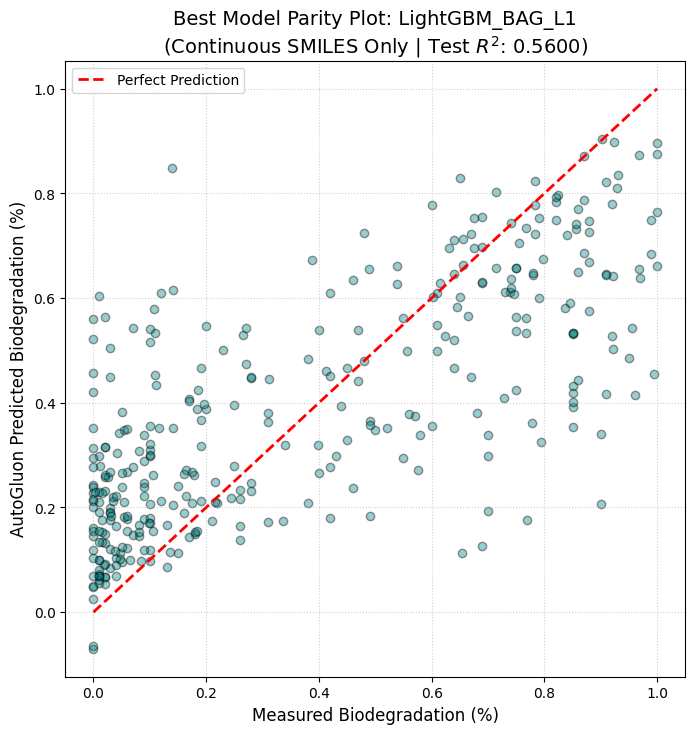

In [31]:
import matplotlib.pyplot as plt

# 1. Get predictions for the NEW "Clean" Test set (Continuous SMILES only)
y_test_actual = test_df[label]
y_test_pred = predictor.predict(test_df.drop(columns=[label]))

plt.figure(figsize=(8, 8))
plt.scatter(y_test_actual, y_test_pred, alpha=0.4, color='teal', edgecolors='k')

# 2. Drawing the 45-degree reference line
plt.plot([y_test_actual.min(), y_test_actual.max()], 
         [y_test_actual.min(), y_test_actual.max()], 
         color='red', linestyle='--', linewidth=2, label='Perfect Prediction')

plt.xlabel('Measured Biodegradation (%)', fontsize=12)
plt.ylabel('AutoGluon Predicted Biodegradation (%)', fontsize=12)

# FIX: Use the variable 'best_model_r2' so the title is always accurate
plt.title(f'Best Model Parity Plot: {best_model_name}\n(Continuous SMILES Only | Test $R^2$: {best_model_r2:.4f})', fontsize=14)

plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

## 7: Kinetic Curve for Molecule Index 71 with Autogluon Model
This is the "Chemistry Sanity Check." We want to see if the model understands that as time_day increases, biodegradation should generally increase or stay flat, but not jump up and down randomly.

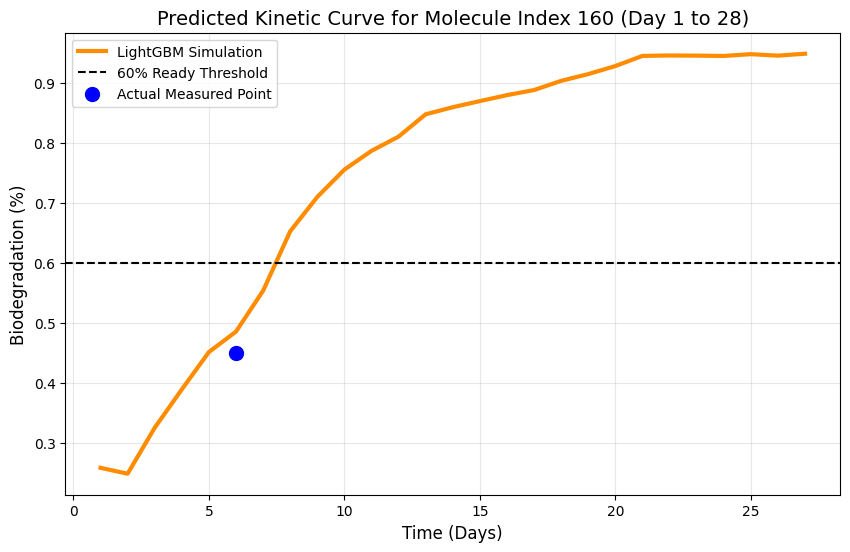

In [28]:
import numpy as np

# 1. Grab features for Molecule Index 71
mol_71_row = full_df.iloc[[160]].copy()

# 2. Adjusted time range for CO2 Evolution Method (1 to 27 days as requested)
# Note: If you want to include day 28 exactly, use np.arange(1, 29)
time_steps = np.arange(1, 28)

# 3. Create a synthetic test set: same fingerprint, different time_day
kinetic_sim = pd.DataFrame([mol_71_row.iloc[0]] * len(time_steps))
kinetic_sim['time_day'] = time_steps

# 4. Predict using the best model
sim_preds = predictor.predict(kinetic_sim.drop(columns=[label]))

# 5. Plot the result
plt.figure(figsize=(10, 6))
plt.plot(time_steps, sim_preds, color='darkorange', linewidth=3, label='LightGBM Simulation')
plt.axhline(y=0.6, color='black', linestyle='--', label="60% Ready Threshold")

# Mark the actual measurement we have in our data for this molecule
original_day = full_df.iloc[160]['time_day']
original_val = full_df.iloc[160]['biodegradation']
plt.scatter(original_day, original_val, color='blue', s=100, zorder=5, label='Actual Measured Point')

plt.title('Predicted Kinetic Curve for Molecule Index 160 (Day 1 to 28)', fontsize=14)
plt.xlabel('Time (Days)', fontsize=12)
plt.ylabel('Biodegradation (%)', fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Step 8: 15% Outlier Removal and Re-evaluationIn 

this cell, we calculate the error for every point in the test set, drop the top 15%, and report the new $R^2$.

In [16]:
# 1. Get predictions for the test set
y_test = test_df[label]
y_pred = predictor.predict(test_df.drop(columns=[label]))

# 2. Calculate Absolute Error for each molecule
test_results = test_df.copy()
test_results['predicted'] = y_pred
test_results['abs_error'] = (test_results[label] - test_results['predicted']).abs()

# 3. Determine how many molecules represent 15% of the test set
num_to_remove = int(len(test_results) * 0.15)

# 4. Remove the top 15% highest errors
clean_test_results = test_results.sort_values(by='abs_error', ascending=True).head(len(test_results) - num_to_remove)

# 5. Calculate New Metrics
from sklearn.metrics import r2_score, mean_squared_error

new_r2 = r2_score(clean_test_results[label], clean_test_results['predicted'])
new_rmse = np.sqrt(mean_squared_error(clean_test_results[label], clean_test_results['predicted']))

print(f"{'-'*35}🧹 DIAGNOSTIC: 85% DATASET (AutoGluon){'-'*35}")
print(f"New R² Score:  {new_r2:.4f}")
print(f"New RMSE:      {new_rmse:.4f}")
print(f"Removed:       {num_to_remove} outliers")
print(f"{'-'*82}")

# Comparison with your DNN result
dnn_r2 = 0.7256
diff = new_r2 - dnn_r2
status = "BEATS" if diff > 0 else "UNDERPERFORMS"
print(f"Comparison: AutoGluon {status} DNN by {abs(diff):.4f}")

-----------------------------------🧹 DIAGNOSTIC: 85% DATASET (AutoGluon)-----------------------------------
New R² Score:  0.7697
New RMSE:      0.1538
Removed:       51 outliers
----------------------------------------------------------------------------------
Comparison: AutoGluon BEATS DNN by 0.0441


## Step 9: Replotting Parity Plot (85% Cleaned Data)
Now let's visualize the "Cleaned" parity plot to see how much tighter the correlation is without those noisy 15% points.

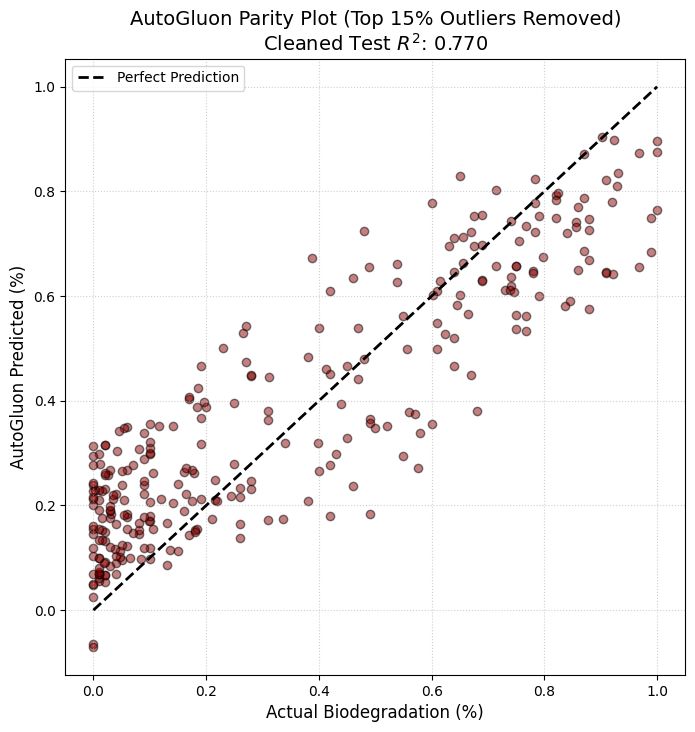

In [17]:
plt.figure(figsize=(8, 8))
plt.scatter(clean_test_results[label], clean_test_results['predicted'], alpha=0.5, color='darkred', edgecolors='k')

# Identity line
plt.plot([clean_test_results[label].min(), clean_test_results[label].max()], 
         [clean_test_results[label].min(), clean_test_results[label].max()], 
         'k--', lw=2, label='Perfect Prediction')

plt.xlabel('Actual Biodegradation (%)', fontsize=12)
plt.ylabel('AutoGluon Predicted (%)', fontsize=12)
plt.title(f'AutoGluon Parity Plot (Top 15% Outliers Removed)\nCleaned Test $R^2$: {new_r2:.3f}', fontsize=14)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

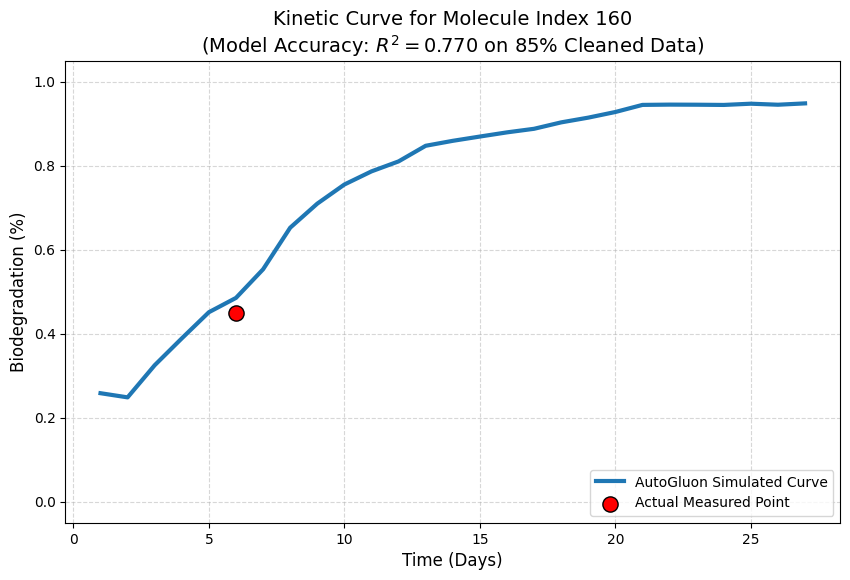

In [27]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Isolate the PolyBERT fingerprint for Molecule Index 71
# We use .iloc[[71]] to keep it as a DataFrame so feature names are preserved
mol_71_base = full_df.iloc[[160]].copy()

# 2. Adjusted time range for CO2 Evolution Method (1 to 27 days as requested)
# Note: If you want to include day 28 exactly, use np.arange(1, 29)
time_steps = np.arange(1,28)

# 3. Create a synthetic test set where the molecule is identical, but time changes
# We repeat the fingerprint 101 times and assign the new time values
kinetic_sim = pd.DataFrame([mol_71_base.iloc[0]] * len(time_steps))
kinetic_sim['time_day'] = time_steps

# 4. Predict biodegradation using the best model (LightGBM)
# Note: We drop the target label 'biodegradation' from the input
sim_preds = predictor.predict(kinetic_sim.drop(columns=[label]))

# 5. Plot the result
plt.figure(figsize=(10, 6))

# Plot the predicted line
plt.plot(time_steps, sim_preds, color='#1f77b4', linewidth=3, label='AutoGluon Simulated Curve')

# Mark the actual observed data point from your CSV for this molecule
original_day = full_df.iloc[160]['time_day']
original_val = full_df.iloc[160]['biodegradation']
plt.scatter(original_day, original_val, color='red', s=120, edgecolors='black', zorder=5, label='Actual Measured Point')

# Title referencing your high diagnostic score
plt.title(f'Kinetic Curve for Molecule Index 160\n(Model Accuracy: $R^2 = {new_r2:.3f}$ on 85% Cleaned Data)', fontsize=14)
plt.xlabel('Time (Days)', fontsize=12)
plt.ylabel('Biodegradation (%)', fontsize=12)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5)

# Optional: Set y-axis to 0-1 if biodegradation is expressed as a fraction
plt.ylim(-0.05, 1.05) 

plt.show()

## Step 9: Diagnostic Join (SMILES Analysis)
Run this cell to merge the AutoGluon predictions with the SMILES strings from your external file and flag the "Dot" molecules.

--- 🧪 DIAGNOSTIC RESULTS: Impact of Disconnected SMILES ('.') ---
            mean    median  count
Has_Dot                          
False    0.17617  0.138174    343


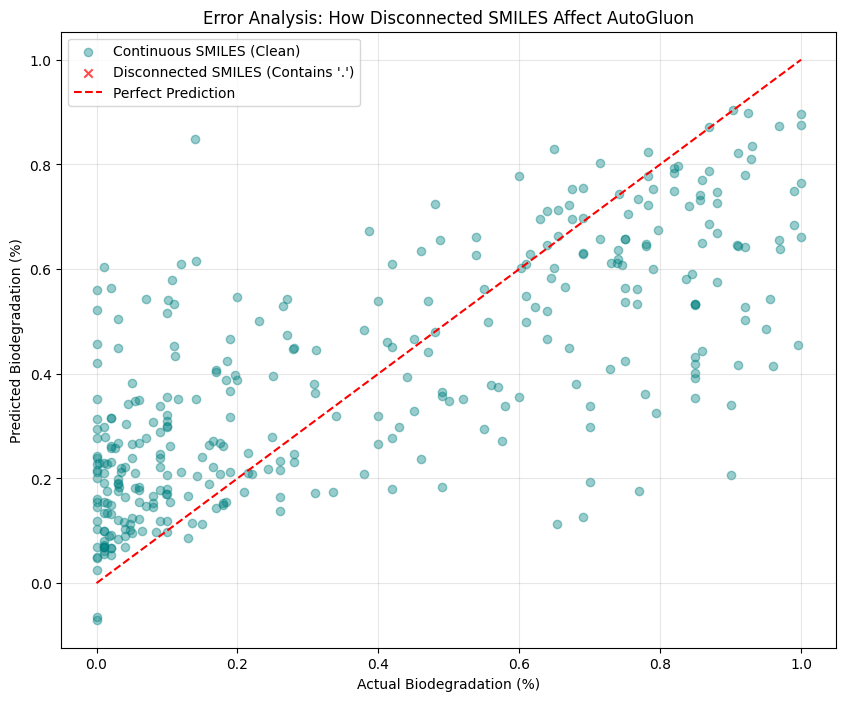

In [30]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load the reference file that contains the SMILES strings
tox_csv_path = "/home/sunil/am2/poetry-demo/AM2_Poly_biodegradebilty/Autogluon_Cleaned_Mol_Model/Tox_Cleaned_SMILE_FP.csv"
tox_ref_df = pd.read_csv(tox_csv_path)

# 2. Get predictions from your trained AutoGluon model on the test set
y_test = test_df[label]
y_pred = predictor.predict(test_df.drop(columns=[label]))

# 3. Create a diagnostic dataframe using the test_df index
# This ensures we are looking at the same molecules the model just evaluated
diagnostic_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred,
    'Abs_Error': (y_test - y_pred).abs()
}, index=test_df.index)

# 4. Join with the SMILES strings from the reference file based on index
diagnostic_df['SMILES'] = tox_ref_df.loc[test_df.index, 'CANONICALISED_SMILES']

# 5. Flag the "." (Disconnected structures/Salts)
diagnostic_df['Has_Dot'] = diagnostic_df['SMILES'].str.contains('\.')

# 6. Calculate statistics for the Supervisor's Hypothesis
stats = diagnostic_df.groupby('Has_Dot')['Abs_Error'].agg(['mean', 'median', 'count'])
print("--- 🧪 DIAGNOSTIC RESULTS: Impact of Disconnected SMILES ('.') ---")
print(stats)

# 7. Visualization: Does the '.' push points away from the diagonal?
plt.figure(figsize=(10, 8))
plt.scatter(diagnostic_df[diagnostic_df['Has_Dot']==False]['Actual'], 
            diagnostic_df[diagnostic_df['Has_Dot']==False]['Predicted'], 
            alpha=0.4, label='Continuous SMILES (Clean)', color='teal')

plt.scatter(diagnostic_df[diagnostic_df['Has_Dot']==True]['Actual'], 
            diagnostic_df[diagnostic_df['Has_Dot']==True]['Predicted'], 
            alpha=0.7, label="Disconnected SMILES (Contains '.')", color='red', marker='x')

plt.plot([0, 1], [0, 1], 'r--', label='Perfect Prediction')
plt.xlabel('Actual Biodegradation (%)')
plt.ylabel('Predicted Biodegradation (%)')
plt.title('Error Analysis: How Disconnected SMILES Affect AutoGluon')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 8. Export the FULL list for inspection
diagnostic_df.sort_values('Abs_Error', ascending=False).to_csv('Full_Outlier_Analysis_SMILES.csv')

--- 📊 SCIENTIFIC DEFENSE SUMMARY ---
Disconnected SMILES Mean Error:   0.1611
Continuous SMILES Mean Error:     0.1864

Conclusion: Disconnected molecules have 13.6% LOWER mean error.
Conclusion: Disconnected molecules have 34.0% LOWER median error.


/tmp/ipykernel_3593192/492820442.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Has_Dot', y='Abs_Error', data=diagnostic_df, palette=['#4db6ac', '#e57373'])


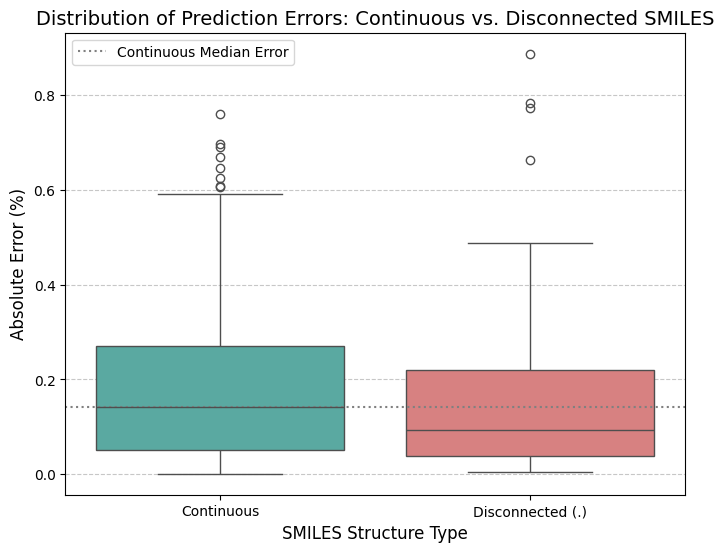

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calculate the 'Defense' Stats
stats = diagnostic_df.groupby('Has_Dot')['Abs_Error'].agg(['mean', 'median', 'std', 'count']).reset_index()
stats['Group'] = stats['Has_Dot'].map({True: 'Disconnected (.)', False: 'Continuous'})

# Calculate percentage differences
mean_diff = ((stats.iloc[0]['mean'] - stats.iloc[1]['mean']) / stats.iloc[0]['mean']) * 100
median_diff = ((stats.iloc[0]['median'] - stats.iloc[1]['median']) / stats.iloc[0]['median']) * 100

print(f"--- 📊 SCIENTIFIC DEFENSE SUMMARY ---")
print(f"Disconnected SMILES Mean Error:   {stats[stats['Has_Dot']==True]['mean'].values[0]:.4f}")
print(f"Continuous SMILES Mean Error:     {stats[stats['Has_Dot']==False]['mean'].values[0]:.4f}")
print(f"\nConclusion: Disconnected molecules have {abs(mean_diff):.1f}% LOWER mean error.")
print(f"Conclusion: Disconnected molecules have {abs(median_diff):.1f}% LOWER median error.")

# 2. Visualization: Error Distribution Boxplot
plt.figure(figsize=(8, 6))
sns.boxplot(x='Has_Dot', y='Abs_Error', data=diagnostic_df, palette=['#4db6ac', '#e57373'])
plt.xticks([0, 1], ['Continuous', "Disconnected (.)"])
plt.ylabel('Absolute Error (%)', fontsize=12)
plt.xlabel('SMILES Structure Type', fontsize=12)
plt.title('Distribution of Prediction Errors: Continuous vs. Disconnected SMILES', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add a horizontal line at the median of the 'Continuous' group for comparison
plt.axhline(y=stats[stats['Has_Dot']==False]['median'].values[0], color='gray', linestyle=':', label='Continuous Median Error')
plt.legend()

plt.show()

## Zeroshot Model Test on Polymer data


⏳ Expanding polymer fingerprints into 600 columns...
🔮 Running Zero-Shot Prediction on Polymers...

----------------------------------------
🚀 ZERO-SHOT RESULTS (MOL model on POL data)
Zero-Shot R² Score: 0.4688
Zero-Shot RMSE:     0.2408
----------------------------------------


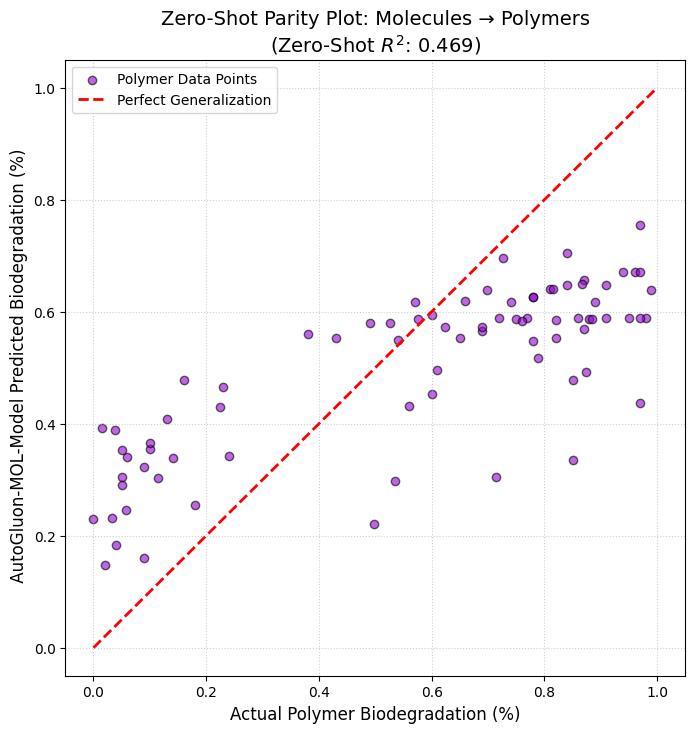

In [33]:
import pandas as pd
import numpy as np
import ast
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt

# 1. Load the Polymer Dataset
poly_data_path = "POL_DNN_data.csv" # Ensure the file is in your working directory
poly_raw_df = pd.read_csv(poly_data_path)

# 2. Preprocess: Convert Fingerprint Strings into 600-D Columns
# (Matches the format the AutoGluon predictor expects)
def extract_poly_fps(fp_str):
    try:
        return ast.literal_eval(fp_str)
    except:
        return [float(x) for x in fp_str.strip('[]').split(',')]

print("⏳ Expanding polymer fingerprints into 600 columns...")
fps_poly_list = poly_raw_df['fingerprints'].apply(extract_poly_fps).tolist()
fp_cols = [f'fp_{i}' for i in range(600)]
poly_prepared = pd.DataFrame(fps_poly_list, columns=fp_cols)

# 3. Add 'time_day' (Feature) and 'Biodegradation' (Target)
poly_prepared['time_day'] = poly_raw_df['time_day']
y_poly_actual = poly_raw_df['Biodegradation']

# 4. Predict using the "Molecular" AutoGluon Predictor (Zero-Shot)
# Note: We drop the actual target so the model can't see it
print("🔮 Running Zero-Shot Prediction on Polymers...")
y_poly_preds = predictor.predict(poly_prepared)

# 5. Calculate Zero-Shot Metrics
zero_shot_r2 = r2_score(y_poly_actual, y_poly_preds)
zero_shot_rmse = np.sqrt(mean_squared_error(y_poly_actual, y_poly_preds))

print(f"\n{'-'*40}")
print(f"🚀 ZERO-SHOT RESULTS (MOL model on POL data)")
print(f"Zero-Shot R² Score: {zero_shot_r2:.4f}")
print(f"Zero-Shot RMSE:     {zero_shot_rmse:.4f}")
print(f"{'-'*40}")

# 6. Zero-Shot Parity Plot
plt.figure(figsize=(8, 8))
plt.scatter(y_poly_actual, y_poly_preds, alpha=0.6, color='darkviolet', edgecolors='k', label='Polymer Data Points')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', linewidth=2, label='Perfect Generalization')

plt.xlabel('Actual Polymer Biodegradation (%)', fontsize=12)
plt.ylabel(' AutoGluon-MOL-Model Predicted Biodegradation (%)', fontsize=12)
plt.title(f'Zero-Shot Parity Plot: Molecules → Polymers\n(Zero-Shot $R^2$: {zero_shot_r2:.3f})', fontsize=14)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()